# Python Notebook to remove background and align

In [1]:
# importing all the relevant libraries 
import numpy as np
import astroalign as aa
import matplotlib.pyplot as plt
import ccdproc
import os
import astropy.io.fits as fits
from ccdproc import CCDData, combiner
from astropy import units as u
from astropy.time import Time
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.detection import DAOStarFinder
from photutils.background import Background2D
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
from pathlib import Path
import gc
gc.enable()

In [2]:
# ignoring warnings
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("astropy").setLevel(logging.WARNING)

### Ensure the folders are setup correctly 
All image files should be in a folder named "NGC_2547_sub"

Input variables, select the star positions for each band

In [3]:
# reference images for automatic alignment
aa_refidk = [100, 100, 100]

# folder name with images
im_dir = "NGC_2547_sub/"

## Python Functions

### Band Selector Variable Assignments

In [4]:
def band_sel(fidx):
    # Band Variables
    bands = ["b", "g", "r"]

    band = bands[fidx]
    fn_name = '*_'+band + '.fit'
    refidx = aa_refidk[fidx]
    return fn_name, refidx, band

### Non Uniform Background Subtraction

In [5]:
def bkg_subtraction(fidx):
    fn_name, refidx, band = band_sel(fidx)
    print(f"\n-------------- Begin Data Processing for", band, "Images --------------")

    # Collate images into scim----------------------------
    images = ccdproc.ImageFileCollection(im_dir, glob_include=fn_name)

    scim = []
    newname = []
    for fn in images.files_filtered():
        scim.append(CCDData.read(im_dir + fn, unit = "adu")) 

        # Update scim with the correct time meta data
        times = scim[-1].header['DATE-OBS']         # Get the time
        t = Time(times, format='isot', scale='utc') # Read the time from UTC format
        scim[-1].header['MJD-OBS'] = (float(t.mjd), 'MJD')      

        # creating new filename for automatic alignment
        newname.extend(["aa"+fn])        
    print("Images collected: ", len(scim))

    # performing background subtracting and finding median backgrounds
    bkg_meds = []
    for idk, thisimage in enumerate(scim):
        # Model the data using a 50x50 box size for smoothing 
        im_bkg = Background2D(scim[idk], 50)
        # Background medians updating to array 
        bkg_meds = np.append(bkg_meds, im_bkg.background_median.value)

        # removing background in image
        scim[idk].data = scim[idk].data - im_bkg.background.value
    print(band,"-band Background Subtraction completed")   

    # selecting threshold median background value to exlude
    med_1sig = np.mean(bkg_meds) + 0.5*np.std(bkg_meds)
    print(f"\nMedian background: \t{np.mean(bkg_meds):.2f}")
    print(f"Threshold background: \t{med_1sig:.2f}")

    # saving background median values to text file
    np.savetxt("background/"+band+"_bkg_meds.txt", bkg_meds)
    print(f"\nBackground values saved in txt file")

    return med_1sig, scim, bkg_meds, newname



### Automatic Alignment

In [6]:
def autom_align(fidx): 
    med_1sig, scim, bkg_meds, newname = bkg_subtraction(fidx)
    
    # Generate data from band of interest
    fn_name, refidx, band = band_sel(fidx)
    print(f"\nBeginning Image Alignment")

    # Completing Image Alignment
    num_excl = 0
    for idx, thisimage in enumerate(scim):
        # Define images to be shifted
        # Plus zero is a quirky fix to an endian issue (old school)
        img_ref=scim[refidx].data+0       # Alignment Reference image
        img_example=scim[idx].data+0      # Image to be shifted image
        
        # Checking median background of image
        if bkg_meds[idx] <= med_1sig:
            # performing automatic alignment on images with small background
            img_aligned, footprint = aa.register(img_example, img_ref, detection_sigma=5.0, min_area=9, fill_value=-99999.99)
            temp=scim[idx]
            temp.data=img_aligned
            temp.meta = scim[idx].meta
            # Write the image to a file using the new name (aa- prefix)
            temp.write("aligned_images/"+band+"/"+newname[idx], overwrite=True)
        else:
            # Counting number of excluded images
            num_excl = num_excl + 1
    print(f"Image Alignment Completed\n")

    # plotting background for each image ---------------------
    plt.rcParams['font.family'] = 'Times New Roman'
    x = np.arange(0, len(bkg_meds))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, bkg_meds, marker='o', linestyle="", markersize = 1.5)

    # Horizontal lines
    ax.axhline(med_1sig, color='green', linestyle='--', label=r'+0.5$\sigma$')
    ax.axhline(np.mean(bkg_meds), color='red', linestyle='--', label=f'Median ={np.mean(bkg_meds):.2f} ADU')
    
    # Green shaded region from bottom of included images
    ax.axhspan(ymin=ax.get_ylim()[0],ymax=med_1sig, color='green', alpha=0.2, label='Images included')
    
    # Labels
    ax.set_xlabel("Image number")
    ax.set_ylabel("Background Median (ADU)")
    ax.set_title(f"NGC 2547 "+band+"-band\n"+str(num_excl)+" images excluded")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(np.arange(x[0], x[-1], 10))
    plt.tight_layout()

    plt.savefig("background/background_median_plot_"+band+".png")
    
    print(f"Background plot saved\n") 

    return

## Executing Code


-------------- Begin Data Processing for b Images --------------
Images collected:  282
b -band Background Subtraction completed

Median background: 	1552.71
Threshold background: 	1624.63

Background values saved in txt file

Beginning Image Alignment
Image Alignment Completed

Background plot saved


-------------- Begin Data Processing for g Images --------------
Images collected:  282
g -band Background Subtraction completed

Median background: 	1936.98
Threshold background: 	2020.50

Background values saved in txt file

Beginning Image Alignment
Image Alignment Completed

Background plot saved


-------------- Begin Data Processing for r Images --------------
Images collected:  282
r -band Background Subtraction completed

Median background: 	1381.07
Threshold background: 	1447.13

Background values saved in txt file

Beginning Image Alignment
Image Alignment Completed

Background plot saved



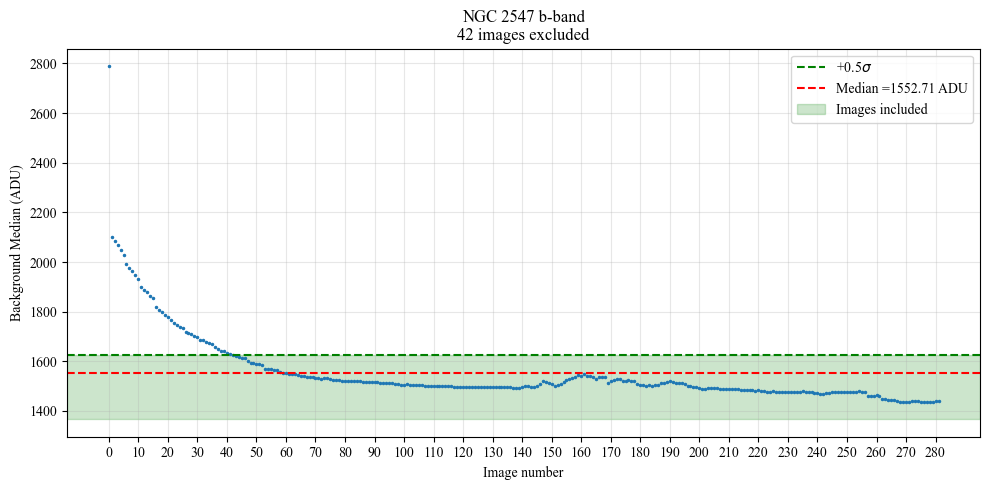

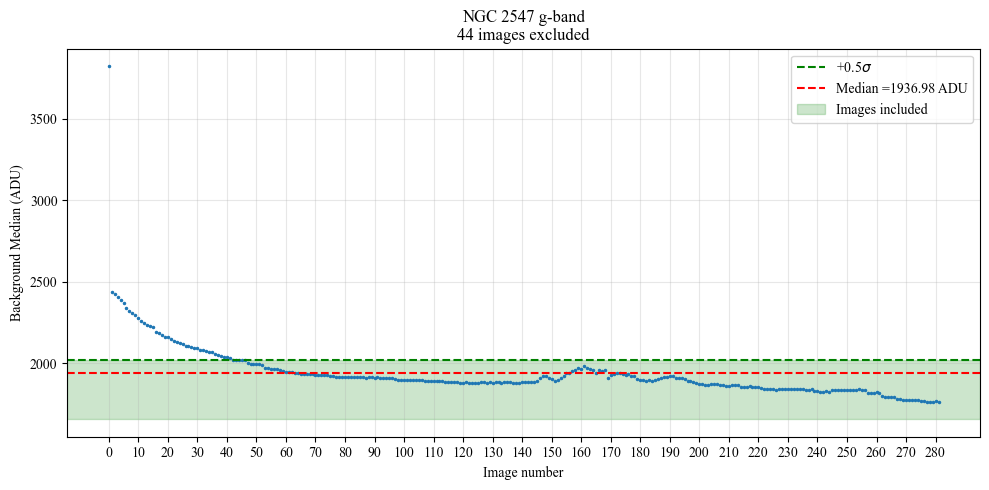

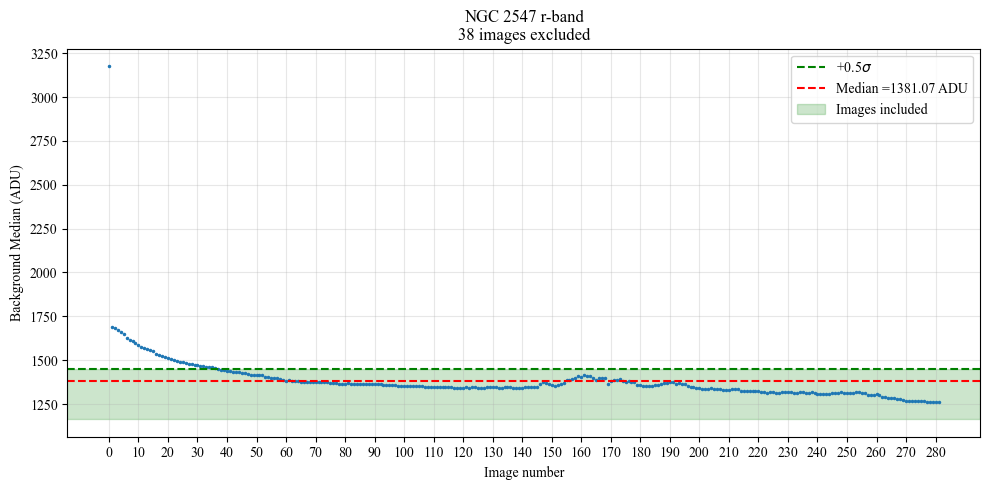

In [7]:
for fidx in range(3):
    autom_align(fidx)